In [1]:
# IMPORTING LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore

import warnings
warnings.filterwarnings('ignore')

In [2]:
# List of CSV files
csv_files = [
    'Youtube01-Psy.csv',
    'Youtube02-KatyPerry.csv',
    'Youtube03-LMFAO.csv',
    'Youtube04-Eminem.csv',
    'Youtube05-Shakira.csv'
]
# Read and combine datasets
all_dataframes = []

for file in csv_files:
    df_temp = pd.read_csv(file)
    all_dataframes.append(df_temp)

# Merge all datasets
df = pd.concat(all_dataframes, ignore_index=True)

In [3]:
# BASIC DATASET INFORMATION
print('First 5 Rows:')
print(df.head())

print('\nDataset Shape:')
print(df.shape)

print('\nColumn Names:')
print(df.columns.tolist())

print('\nDataset Information:')
print(df.info())

First 5 Rows:
                                    COMMENT_ID            AUTHOR  \
0  LZQPQhLyRh80UYxNuaDWhIGQYNQ96IuCg-AYWqNPjpU         Julius NM   
1  LZQPQhLyRh_C2cTtd9MvFRJedxydaVW-2sNg5Diuo4A       adam riyati   
2  LZQPQhLyRh9MSZYnf8djyk0gEF9BHDPYrrK-qCczIY8  Evgeny Murashkin   
3          z13jhp0bxqncu512g22wvzkasxmvvzjaz04   ElNino Melendez   
4          z13fwbwp1oujthgqj04chlngpvzmtt3r3dw            GsMega   

                  DATE                                            CONTENT  \
0  2013-11-07T06:20:48  Huh, anyway check out this you[tube] channel: ...   
1  2013-11-07T12:37:15  Hey guys check out my new channel and our firs...   
2  2013-11-08T17:34:21             just for test I have to say murdev.com   
3  2013-11-09T08:28:43   me shaking my sexy ass on my channel enjoy ^_^ ﻿   
4  2013-11-10T16:05:38            watch?v=vtaRGgvGtWQ   Check this out .﻿   

   CLASS  
0      1  
1      1  
2      1  
3      1  
4      1  

Dataset Shape:
(1956, 5)

Column Names:
['COMME

In [4]:
# CLEANING COLUMN NAMES
# Standardize column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('[^a-zA-Z0-9_]', '', regex=True)
)
print(df.columns)

Index(['comment_id', 'author', 'date', 'content', 'class'], dtype='object')


In [5]:
# MISSING VALUES ANALYSIS
missing_values = df.isnull().sum()

print('Missing Values Per Column:')
print(missing_values)

Missing Values Per Column:
comment_id      0
author          0
date          245
content         0
class           0
dtype: int64


In [6]:
# HANDLE MISSING VALUES
# Numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    if df[col].isnull().sum() > 0:
        median_value = df[col].median()
        df[col].fillna(median_value, inplace=True)

# Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    if df[col].isnull().sum() > 0:
        mode_value = df[col].mode()[0]
        df[col].fillna(mode_value, inplace=True)

In [7]:
# DUPLICATE REMOVAL
before_shape = df.shape

duplicates = df.duplicated().sum()
print(f'Total Duplicate Rows: {duplicates}')

# Remove duplicates
df.drop_duplicates(inplace=True)

after_shape = df.shape

print('\nDataset Shape Before Cleaning:', before_shape)
print('Dataset Shape After Cleaning:', after_shape)

Total Duplicate Rows: 3

Dataset Shape Before Cleaning: (1956, 5)
Dataset Shape After Cleaning: (1953, 5)


In [8]:
# DATA TYPE CONVERSION
# Convert date column
df['date'] = pd.to_datetime(df['date'], errors='coerce')

print(df.dtypes)

comment_id            object
author                object
date          datetime64[ns]
content               object
class                  int64
dtype: object


In [9]:
print(df.dtypes)

# DESCRIPTIVE STATISTICS
print(df.describe(include='all'))

comment_id            object
author                object
date          datetime64[ns]
content               object
class                  int64
dtype: object
                                         comment_id author  \
count                                          1953   1953   
unique                                         1953   1792   
top     _2viQ_Qnc685RPw1aSa1tfrIuHXRvAQ2rPT9R06KTqA  M.E.S   
freq                                              1      8   
mean                                            NaN    NaN   
min                                             NaN    NaN   
25%                                             NaN    NaN   
50%                                             NaN    NaN   
75%                                             NaN    NaN   
max                                             NaN    NaN   
std                                             NaN    NaN   

                                 date                            content  \
count               

In [10]:
# UNIQUE VALUES
for col in df.columns:
    print(f'\nColumn: {col}')
    print(df[col].nunique())


Column: comment_id
1953

Column: author
1792

Column: date
701

Column: content
1760

Column: class
2


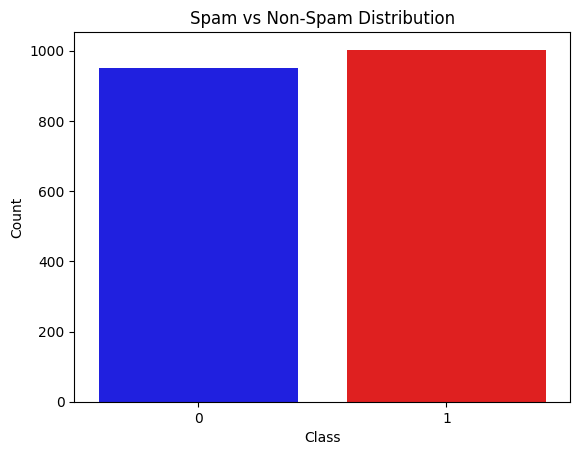

In [11]:
sns.countplot(x='class', data=df, palette={'1': 'red', '0': 'blue'})
plt.title('Spam vs Non-Spam Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [12]:
# COMMENT LENGTH FEATURE
df['comment_length'] = df['content'].astype(str).apply(len)

print(df['comment_length'].describe())

count    1953.000000
mean       94.782386
std       128.297958
min         2.000000
25%        29.000000
50%        48.000000
75%        97.000000
max      1200.000000
Name: comment_length, dtype: float64


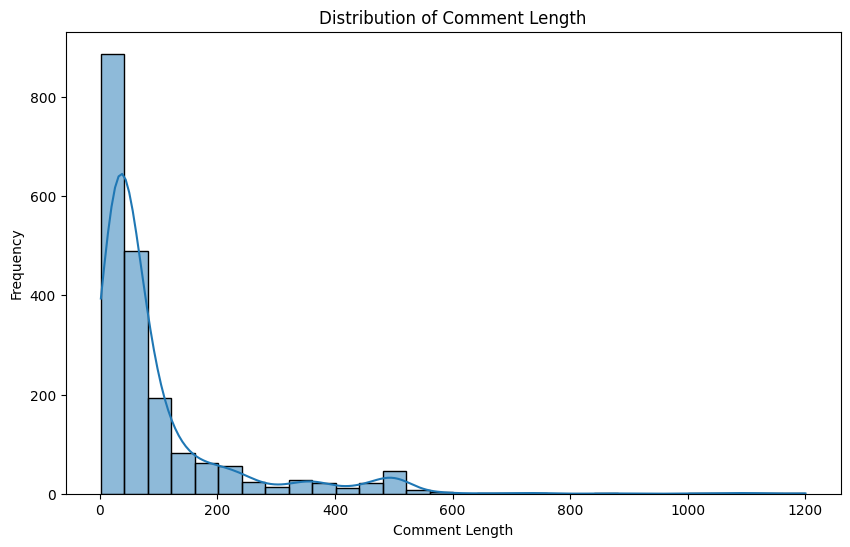

In [13]:
# HISTOGRAM
plt.figure(figsize=(10, 6))

sns.histplot(df['comment_length'], bins=30, kde=True)

plt.title('Distribution of Comment Length')
plt.xlabel('Comment Length')
plt.ylabel('Frequency')

plt.show()

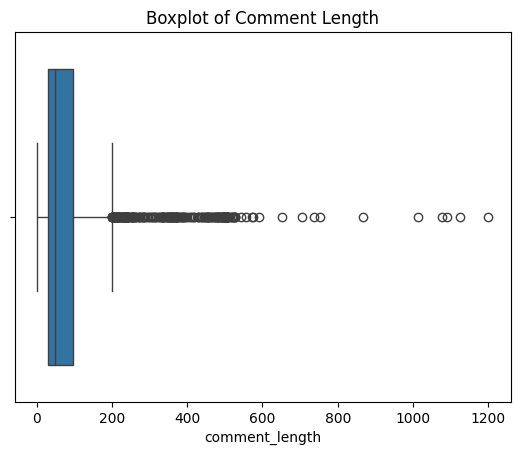

In [14]:
#BOXPLOT
sns.boxplot(x=df['comment_length'])
plt.title('Boxplot of Comment Length')
plt.show()

In [15]:
# OUTLIER DETECTION USING IQR
Q1 = df['comment_length'].quantile(0.25)
Q3 = df['comment_length'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['comment_length'] < lower_bound) |
    (df['comment_length'] > upper_bound)
]

print('Number of Outliers:', outliers.shape[0])

Number of Outliers: 245


In [16]:
# Z-SCORE METHOD
z_scores = np.abs(zscore(df['comment_length']))

outliers_z = df[z_scores > 3]

print('Outliers Detected Using Z-Score:', outliers_z.shape[0])

Outliers Detected Using Z-Score: 65


In [17]:
# WINSORIZATION/CAPPING
df['comment_length'] = np.where(
    df['comment_length'] > upper_bound,
    upper_bound,
    df['comment_length']
)

In [18]:
# LABEL ENCODING
le = LabelEncoder()

# Encode author names
df['author_encoded'] = le.fit_transform(df['author'])

In [19]:
# FEATURE SCALING
scaler = StandardScaler()

scaled_features = scaler.fit_transform(df[['comment_length']])

df['comment_length_scaled'] = scaled_features

In [20]:
# CORRELATION MATRIX
correlation_matrix = df.select_dtypes(include=['int64', 'float64']).corr()

print(correlation_matrix)

                          class  comment_length  author_encoded  \
class                  1.000000        0.390268       -0.041223   
comment_length         0.390268        1.000000       -0.047351   
author_encoded        -0.041223       -0.047351        1.000000   
comment_length_scaled  0.390268        1.000000       -0.047351   

                       comment_length_scaled  
class                               0.390268  
comment_length                      1.000000  
author_encoded                     -0.047351  
comment_length_scaled               1.000000  


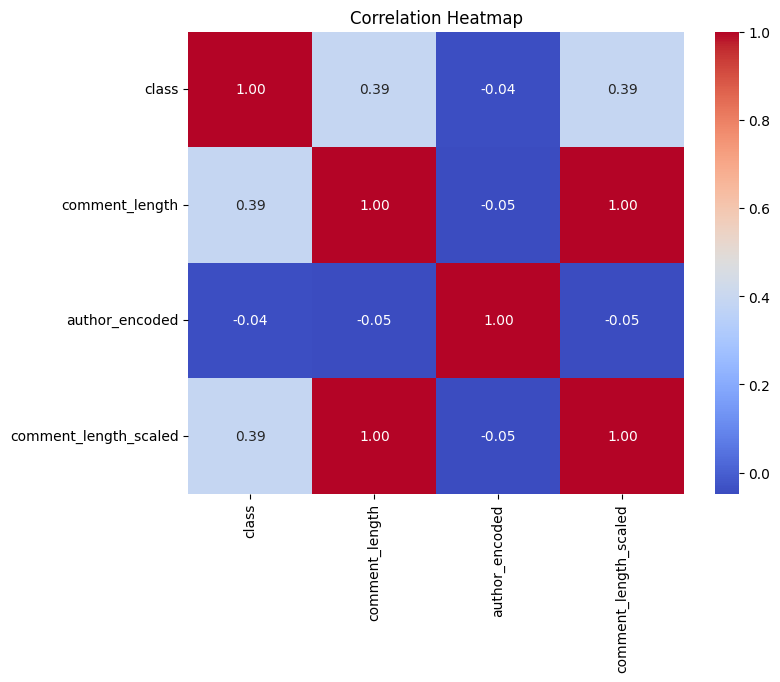

In [21]:
# HEATMAP
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

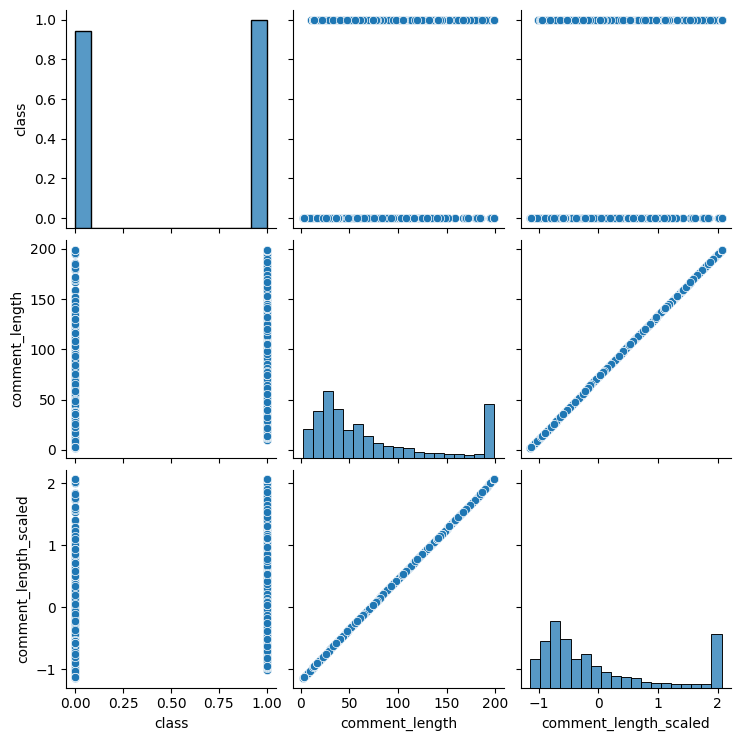

In [22]:
# PAIRPLOT
pairplot_columns = ['class', 'comment_length', 'comment_length_scaled']

sns.pairplot(df[pairplot_columns])
plt.show()

In [23]:
# VALUE COUNTS
for col in cat_cols:
    print(f'\nValue Counts for {col}:')
    print(df[col].value_counts().head(10))


Value Counts for comment_id:
comment_id
_2viQ_Qnc685RPw1aSa1tfrIuHXRvAQ2rPT9R06KTqA    1
_2viQ_Qnc69GH3FQl348HonbRxpbmtsR5CUei0zkJog    1
_2viQ_Qnc6-PfOjDtTwbTalW_5TRtvBKMcHZdDrcI2o    1
z12xc3ly4x3uttmci22xff24nqqxwb0je04            1
_2viQ_Qnc68LpP5gDCaWQuiywObesTUlRgSQExMVMac    1
_2viQ_Qnc6-UzHByAP8y3BxG633jelEC_fxtFRUvLSA    1
_2viQ_Qnc6-3Nk200KmVtS-kiCS_1CjKJsMIbXakyfI    1
_2viQ_Qnc6-G71VMp3dR76dfQTcrRHpiNXJh2jm8V_M    1
_2viQ_Qnc68cxHfQzecR1L9f-hbLNIJ7VxpCZtctPMk    1
_2viQ_Qnc69mci30y5muwQXNMaeCmIvZ4ca8l_4zPmA    1
Name: count, dtype: int64

Value Counts for author:
author
M.E.S              8
Louis Bryant       7
5000palo           7
Shadrach Grentz    7
DanteBTV           6
LuckyMusiqLive     5
Derek Moya         5
Hidden Love        5
AllDailyVines      4
Laura Brown        4
Name: count, dtype: int64

Value Counts for date:
date
2014-11-07 19:33:46    2
2013-11-07 12:37:15    1
2013-11-08 17:34:21    1
2013-11-09 08:28:43    1
2013-11-10 16:05:38    1
2013-11-26 02:55:11 

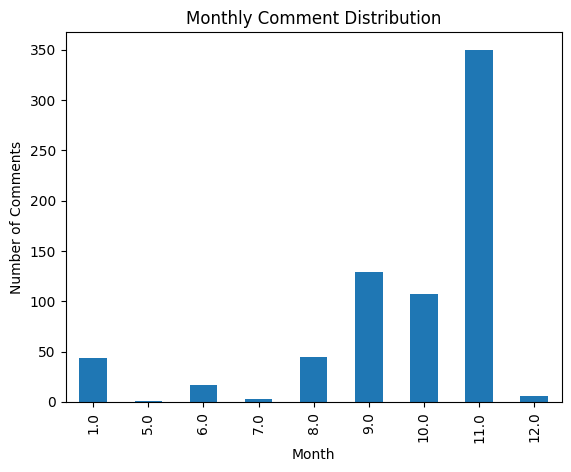

In [24]:
# DATE ANALYSIS
# Extract year and month
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

# Monthly comment count
monthly_comments = df.groupby('month').size()

monthly_comments.plot(kind='bar')
plt.title('Monthly Comment Distribution')
plt.xlabel('Month')
plt.ylabel('Number of Comments')
plt.show()

In [25]:
# FINAL DATASET CHECK
print(df.head())

print('\nFinal Dataset Shape:')
print(df.shape)

print('\nFinal Missing Values:')
print(df.isnull().sum())

                                    comment_id            author  \
0  LZQPQhLyRh80UYxNuaDWhIGQYNQ96IuCg-AYWqNPjpU         Julius NM   
1  LZQPQhLyRh_C2cTtd9MvFRJedxydaVW-2sNg5Diuo4A       adam riyati   
2  LZQPQhLyRh9MSZYnf8djyk0gEF9BHDPYrrK-qCczIY8  Evgeny Murashkin   
3          z13jhp0bxqncu512g22wvzkasxmvvzjaz04   ElNino Melendez   
4          z13fwbwp1oujthgqj04chlngpvzmtt3r3dw            GsMega   

                 date                                            content  \
0 2013-11-07 06:20:48  Huh, anyway check out this you[tube] channel: ...   
1 2013-11-07 12:37:15  Hey guys check out my new channel and our firs...   
2 2013-11-08 17:34:21             just for test I have to say murdev.com   
3 2013-11-09 08:28:43   me shaking my sexy ass on my channel enjoy ^_^ ﻿   
4 2013-11-10 16:05:38            watch?v=vtaRGgvGtWQ   Check this out .﻿   

   class  comment_length  author_encoded  comment_length_scaled    year  month  
0      1            56.0             683             